In [8]:
try:
    import numpy as np
    import matplotlib.pyplot as plt
    import pandas as pd
except ModuleNotFoundError:
    %pip install numpy pandas matplotlib 


##The code below should be run on Google Colab

In [9]:

df_train = pd.read_csv('../../content/sample_data/california_housing_train.csv')
df_test = pd.read_csv("../../content/sample_data/california_housing_test.csv")
X_train = df_train.drop(columns='median_income').to_numpy()
Y_train = df_train['median_income'].to_numpy()
X_test = df_test.drop(columns='median_income').to_numpy()
Y_test = df_test["median_income"].to_numpy()


Normalization


In [10]:
mu = np.mean(X_train, axis=0)
sigma = np.std(X_train, axis=0)

X_train = (X_train - mu)/ sigma
X_test = np.array(X_test)
X_test = (X_test - mu)/ sigma

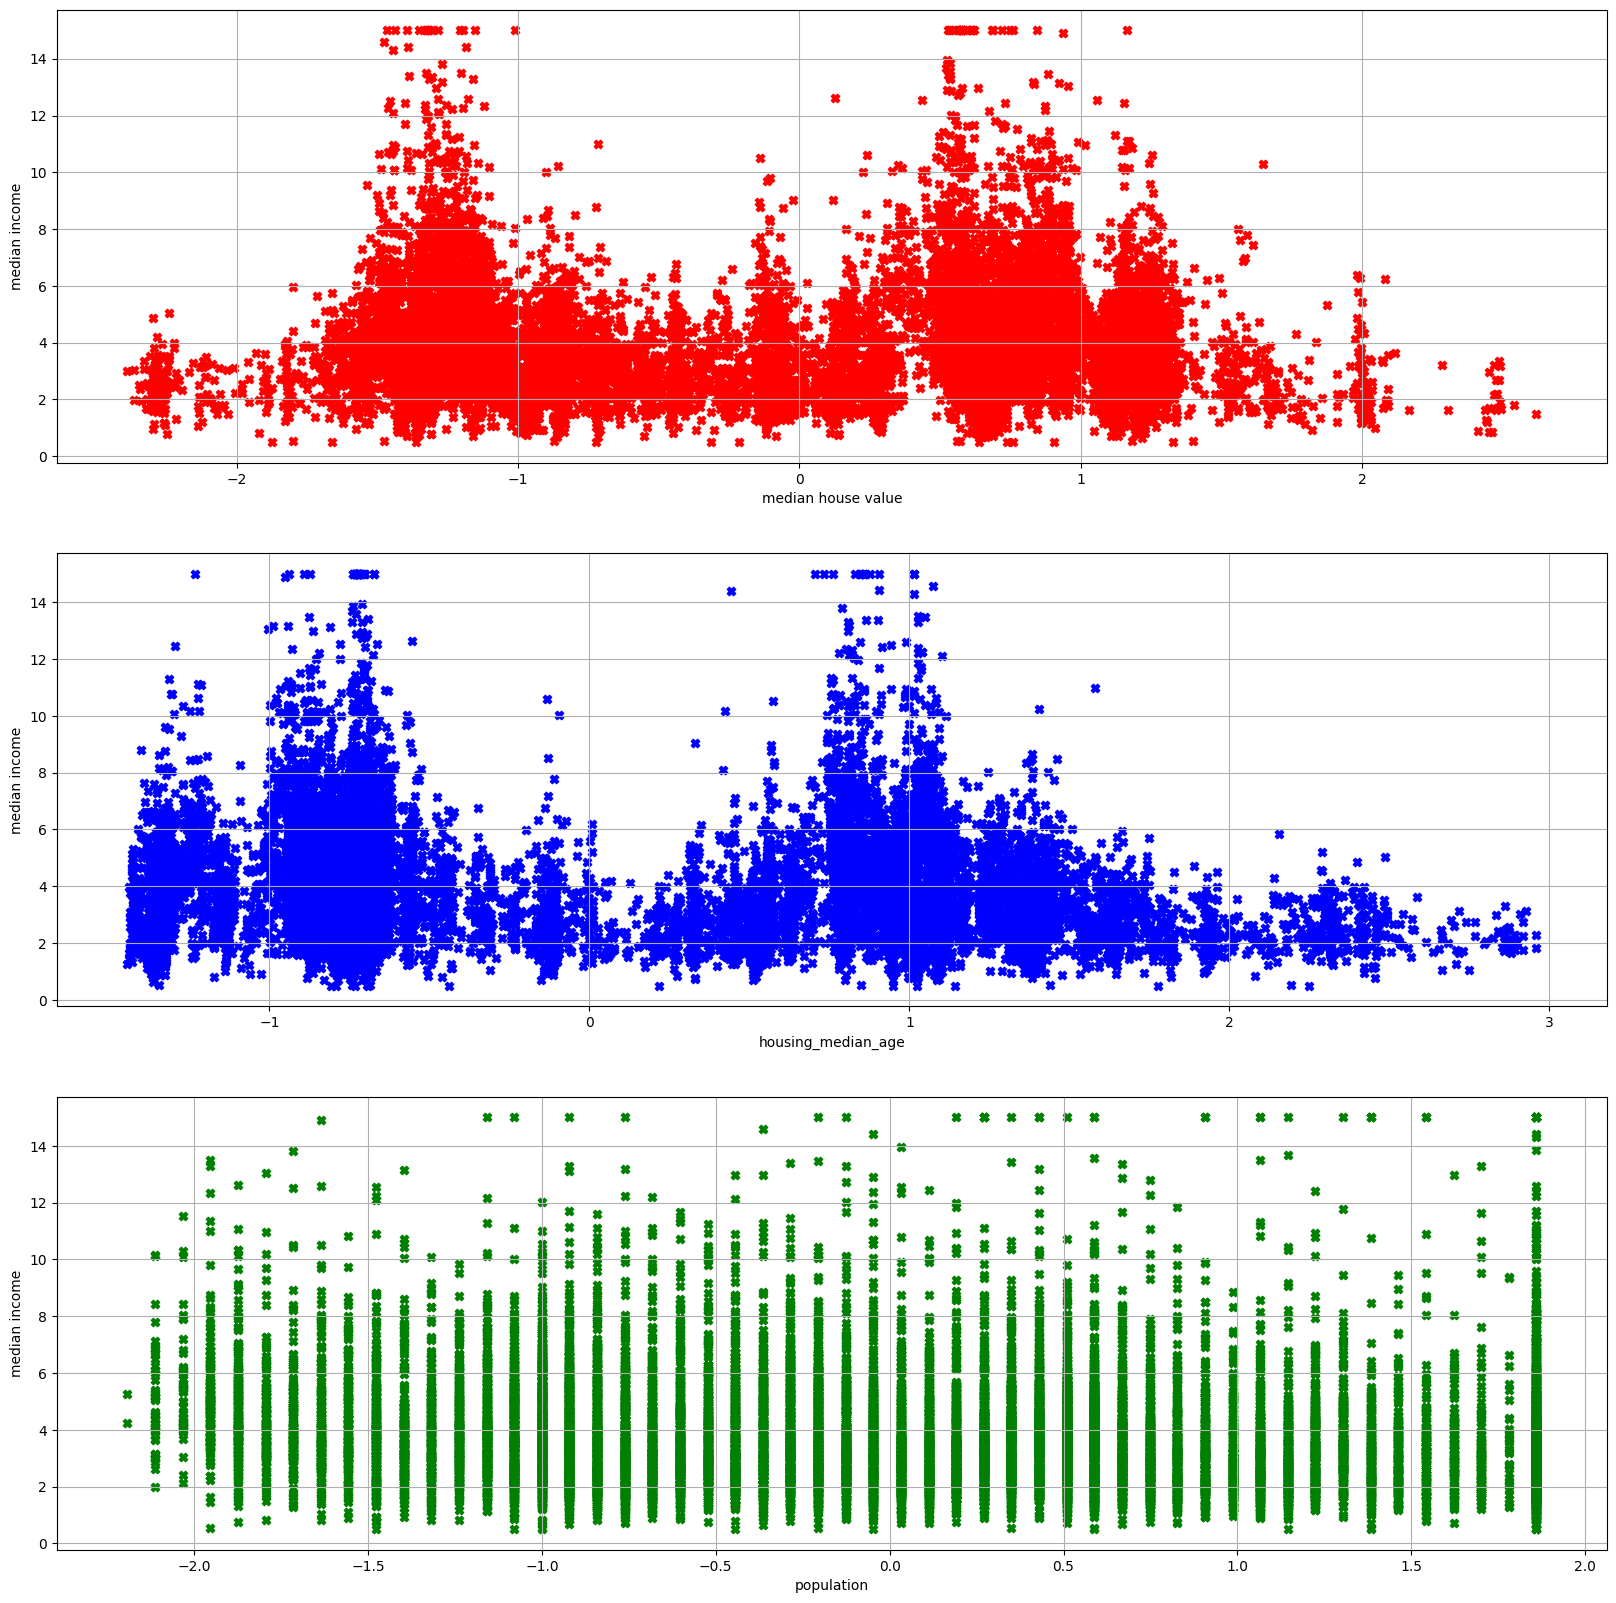

In [11]:


graficos, (g1, g2, g3) = plt.subplots(3, 1, figsize=(20, 20))
g1.scatter(X_train[0:,0], Y_train, marker = "X", color="red")
g1.set_ylabel("median income")
g1.set_xlabel("median house value")
g1.grid(True)

g2.scatter(X_train[0:,1], Y_train, marker = "X", color="blue")
g2.set_ylabel("median income")
g2.set_xlabel("housing_median_age")
g2.grid(True)

g3.scatter(X_train[0:,2], Y_train, marker = "X", color="green")
g3.set_ylabel("median income")
g3.set_xlabel("population")
g3.grid(True)


In [12]:
def compute_fwb(w, b, x):

  fwb = np.dot(x,w) + b
  return fwb

In [13]:
def compute_cost(x, y, w, b):
    # m = x.shape[0]
    # cost = 0
    # for i in range(m):
    #     fwb = computar_fwb(w, b, x[i])
    #     cost += (fwb - y[i])**2
    # return cost / (2 * m)
    #versão vetorizada:

    m = x.shape[0]
    fwb = compute_fwb(w, b, x)
    cost = np.sum((fwb - y)**2)

    return cost / (2 * m)

In [14]:
def compute_partial_derivatives(x, y, w, b):
  dj_dw = np.array(w.shape)
  m = x.shape[0]
  # for i in range(m):
  #   fwb = computar_fwb(w, b, x[i])
  #   dj_dw += (fwb - y[i]) * x[i]
  #   dj_db += (fwb - y[i])

  # dj_db = dj_db / m
  # dj_dw = dj_dw / m
  # aplicando vetorização:

  fwb = compute_fwb(w, b, x)
  error = fwb - y
  dj_dw = np.dot(error, x) / m
  dj_db = np.sum(error) / m


  return dj_dw, dj_db


In [15]:
def compute_gd(alpha, x, y, w, b, iterations):
  cost_history = []
  last_cost = compute_cost(x, y, w, b)
  for i in range(iterations):



    dj_dw, dj_db = compute_partial_derivatives(x, y, w, b)
    tmp_w = w - alpha * dj_dw
    tmp_b = b - alpha * dj_db
    w = tmp_w
    b = tmp_b
    cost = compute_cost(x, y, w, b)
    cost_history.append(cost)
    # if abs(last_cost - cost) < 1.0e-5:
    #   break
    # last_cost = cost
    if i % (iterations//10) == 0:
      print(f"iteration {i} → cost {compute_cost(x, y, w, b)}\nw = {w}, b = {b}\n")

  plt.plot(range(iterations), cost_history)
  plt.ylabel("cost")
  plt.xlabel("iterations")

  return w, b


In [16]:
w_init = np.zeros(X_train.shape[1])
compute_fwb(w_init, 0, X_train[0,:])
compute_cost( X_train, Y_train, w_init, 0)

np.float64(9.361512988677942)

iteration 0 → cost 2.993565440318014
w = [-1.47734305e-02 -7.66131062e-02 -1.10604589e-01  1.86405006e-01
 -1.28746043e-02 -6.08330206e-04  7.29248895e-03  6.60079286e-01], b = 1.94178905

iteration 1000 → cost 0.6116331092106321
w = [ 0.08306224  0.04117851 -0.27090637  1.96910357 -2.2115369   0.02874424
  0.19155043  1.19120913], b = 3.8835781000000003

iteration 2000 → cost 0.6116331012943684
w = [ 0.08313321  0.04123785 -0.27090567  1.96918965 -2.21223217  0.02860689
  0.19229065  1.19119215], b = 3.8835781000000003

iteration 3000 → cost 0.6116331012943658
w = [ 0.08313325  0.04123788 -0.27090567  1.9691897  -2.21223258  0.02860681
  0.19229108  1.19119214], b = 3.8835781000000003

iteration 4000 → cost 0.6116331012943658
w = [ 0.08313325  0.04123788 -0.27090567  1.9691897  -2.21223258  0.02860681
  0.19229108  1.19119214], b = 3.8835781000000003

iteration 5000 → cost 0.6116331012943658
w = [ 0.08313325  0.04123788 -0.27090567  1.9691897  -2.21223258  0.02860681
  0.19229108  1.1

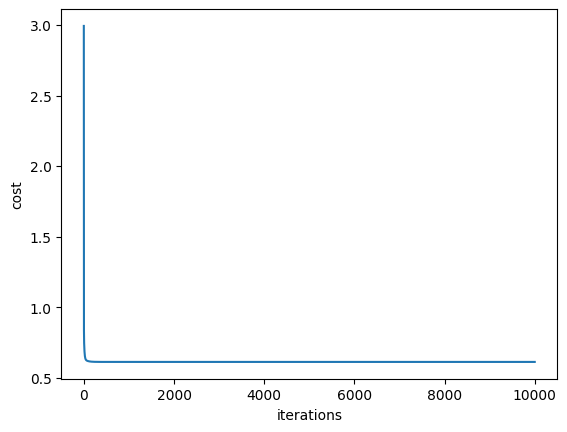

In [17]:
import time
tic = time.time()

w, b = compute_gd(0.5, X_train, Y_train, w_init, 0, 10000)
toc = time.time()
print("running time", toc - tic)

8
8 (8,) <class 'numpy.ndarray'>


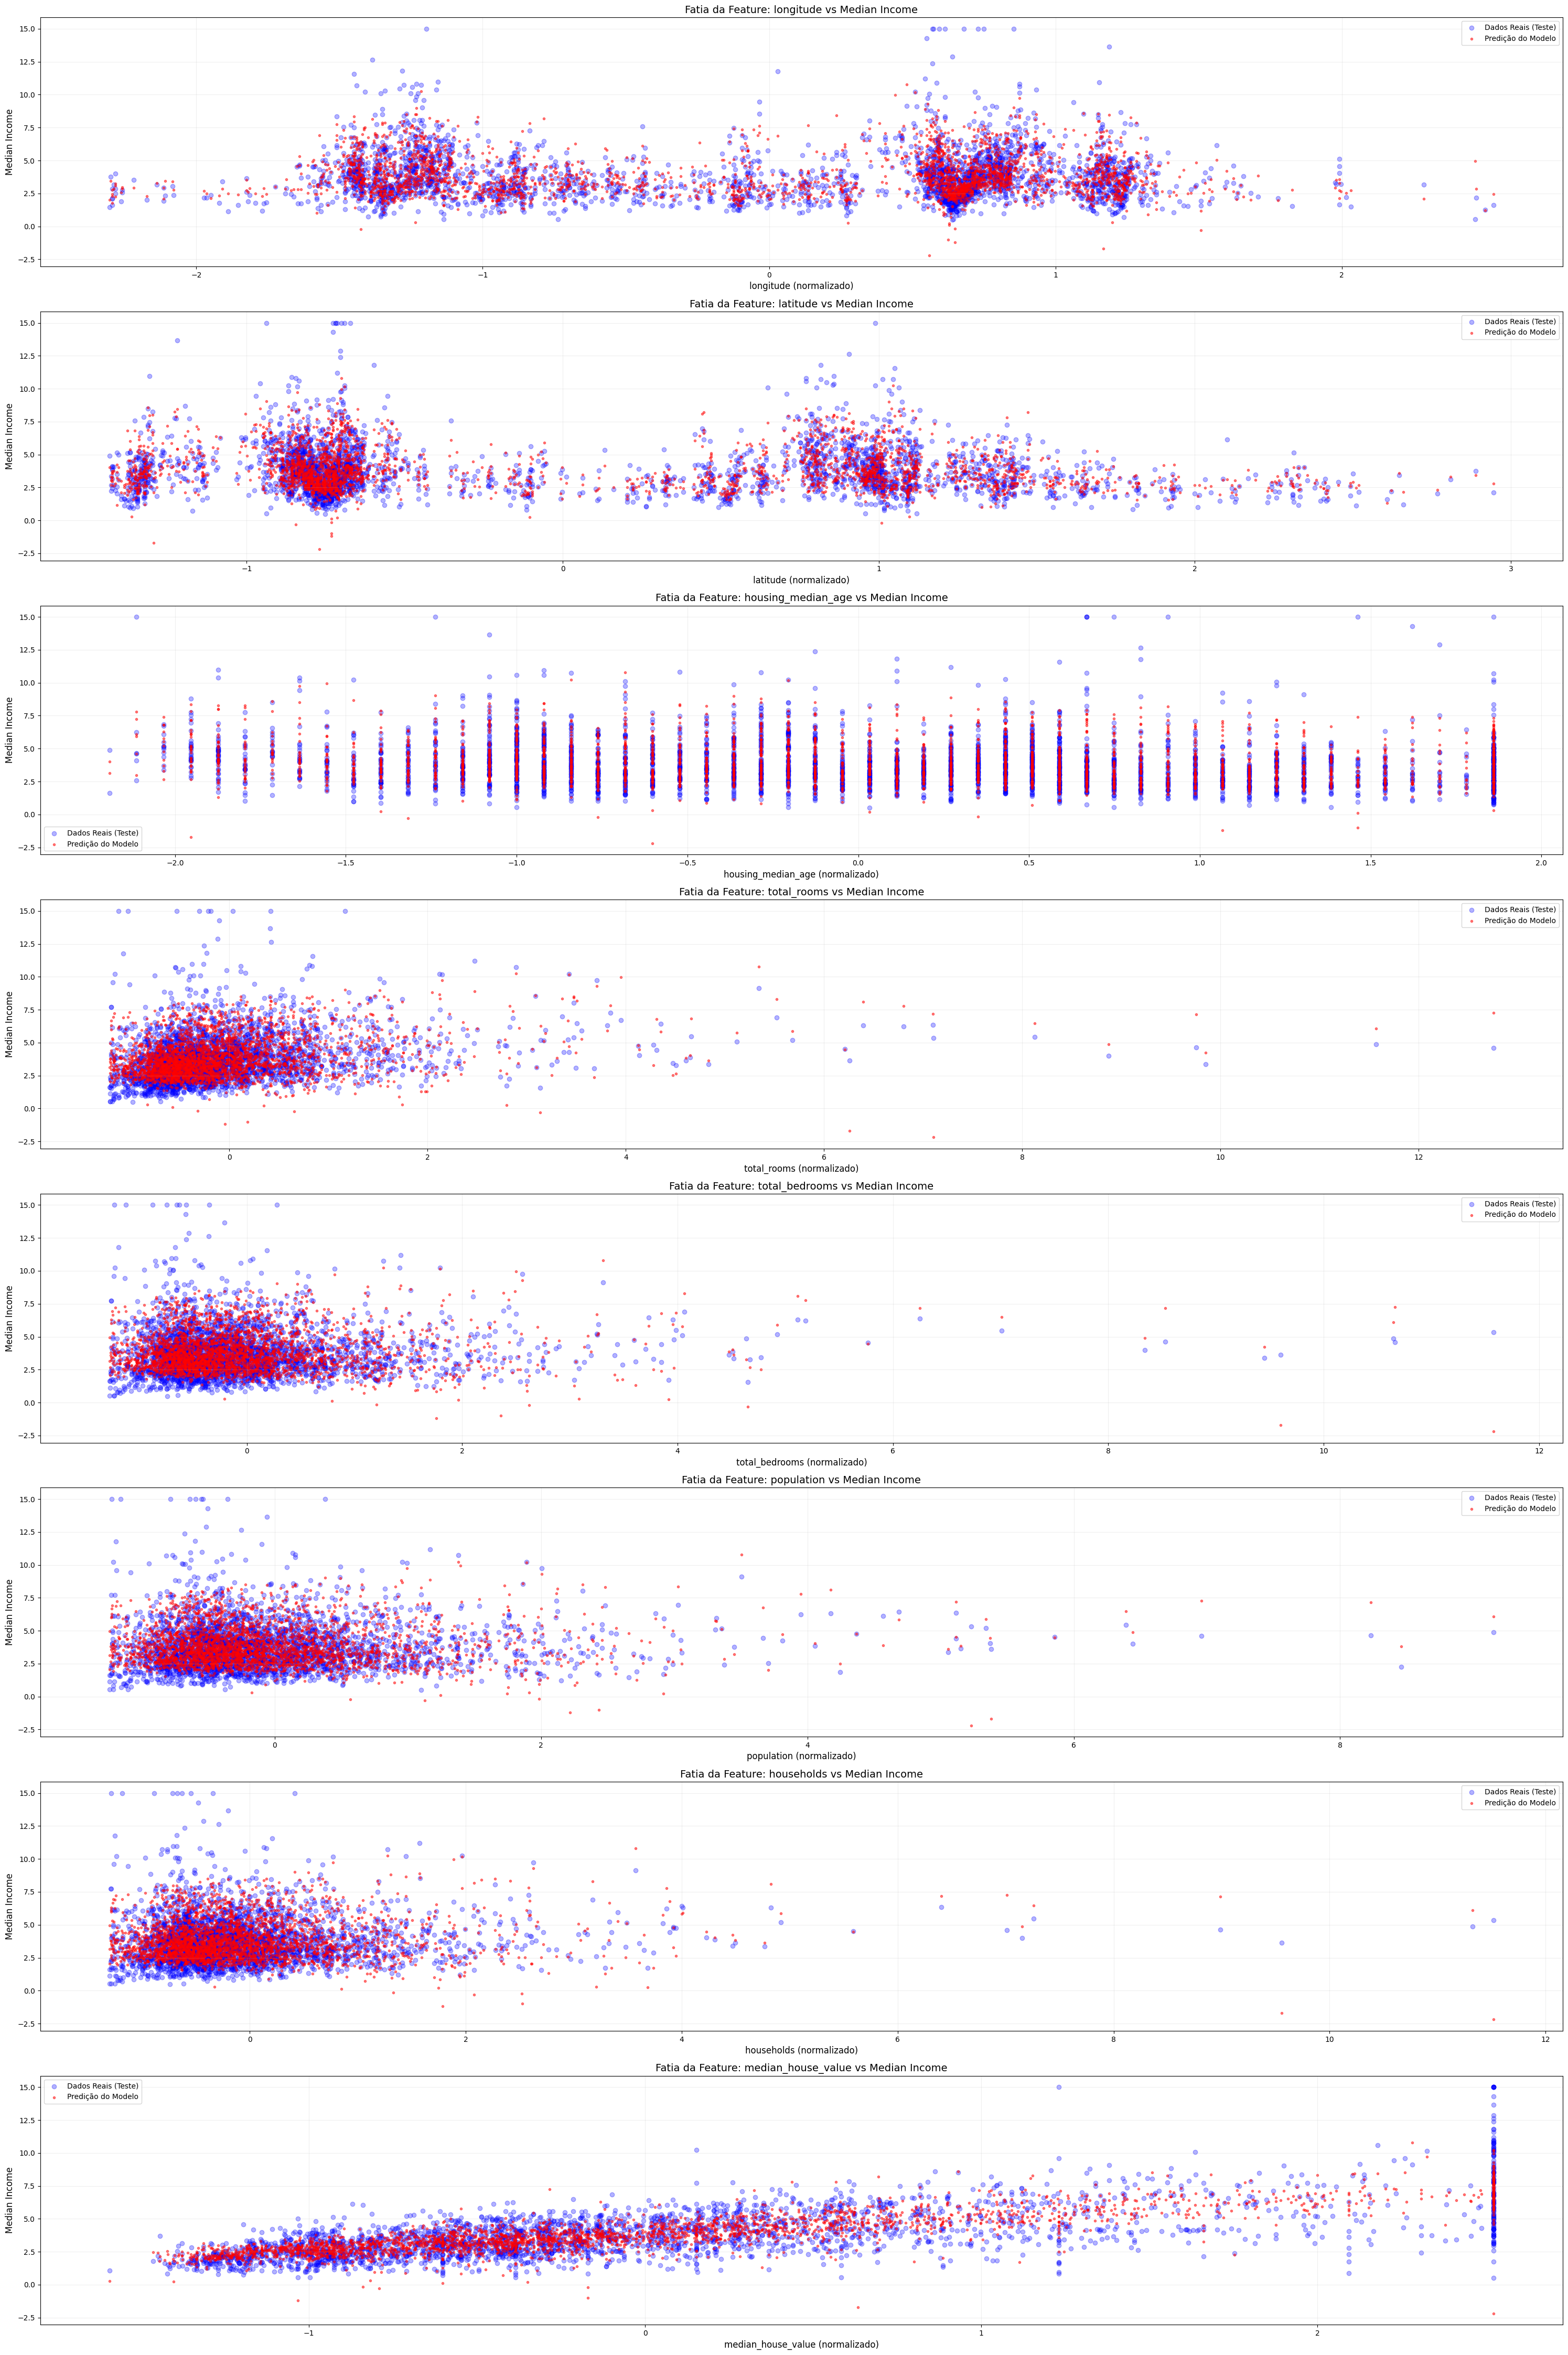

In [18]:
predictions = compute_fwb(w, b, X_test)

features_names = list(df_test.drop(columns='median_income').columns)
num_features = len(features_names)
print(num_features)
fig, axes = plt.subplots(num_features, 1, figsize=(30, 45))
print(num_features, axes.shape, type(axes))
for i in range(num_features):

    axes[i].scatter(X_test[:, i], Y_test,
                    color='blue', alpha=0.3, label='Dados Reais (Teste)')

    axes[i].scatter(X_test[:, i], predictions,
                    color='red', alpha=0.5, marker='.', label='Predição do Modelo')

    axes[i].set_title(f'Fatia da Feature: {features_names[i]} vs Median Income', fontsize=14)
    axes[i].set_xlabel(f'{features_names[i]} (normalizado)', fontsize=12)
    axes[i].set_ylabel('Median Income', fontsize=12)
    axes[i].legend()
    axes[i].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

In [19]:
test_prediction = compute_fwb(w, b, [-114.310000, 34.190000,	15.000000,	5612.000000,	1283.000000,	1015.000000,	472.000000,	1.493600])
print(test_prediction)

8326.101626885598


In [20]:

def regression_metrics(y_true, y_pred):

    m = len(y_true)

    # Errors
    error = y_pred - y_true

    # MSE
    mse = np.mean(error**2)

    # RMSE
    rmse = np.sqrt(mse)

    # MAE
    mae = np.mean(np.abs(error))

    # R²
    ss_res = np.sum(error**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    r2 = 1 - (ss_res / ss_tot)

    # R² ajustado
    n_features = X_test.shape[1]
    r2_adj = 1 - (1 - r2) * (m - 1) / (m - n_features - 1)

    return mse, rmse, mae, r2, r2_adj


mse, rmse, mae, r2, r2_adj = regression_metrics(Y_test, predictions)

print(f"MSE  : {mse:.6f}")
print(f"RMSE : {rmse:.6f}")
print(f"MAE  : {mae:.6f}")
print(f"R²   : {r2:.6f}")
print(f"adjusted R²   : {r2_adj:.6f}")

MSE  : 1.203697
RMSE : 1.097131
MAE  : 0.749215
R²   : 0.649891
adjusted R²   : 0.648955
